In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [10]:
data = pd.read_excel('dieRollsStatic.xlsx')

df = pd.DataFrame(data).drop('Fingers Crossed', axis=1).reset_index() # drop the 'Fingers Crossed' column
#reset index takes the index column a data column

In [11]:
df.head() # print the preview of data

,index,d4,d6,d8,d10,d12,d20,d100
0,0,1,1,6,2,11,2,67
1,1,4,2,5,8,6,8,21
2,2,1,4,6,7,8,20,67
3,3,1,2,1,4,3,16,59
4,4,3,2,7,7,7,8,56


Data Observations
- finger crossed is trying to affect the outcome using faith/mental power
- Dice are rolled 20 times
- every observation is a set of 7 die rolls
- 7 dies are rolled 20 times = 140 observations
- colums can be die type, value and 140 rows

In [21]:
rolledStacked = df.melt(id_vars=['index'], var_name='Die_Type', value_name='Roll_Value') # melt the data

In [24]:
rolledStacked

,index,Die_Type,Roll_Value
0,0,d4,1
1,1,d4,4
2,2,d4,1
3,3,d4,1
4,4,d4,3
...,...,...,...
135,15,d100,31
136,16,d100,61
137,17,d100,38
138,18,d100,56


Text(0.5, 0, 'Die Type')

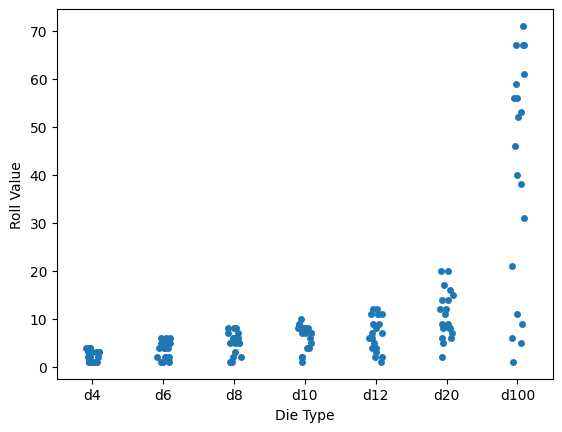

In [26]:
#plots strip plot
plot = sns.stripplot(x='Die_Type', y='Roll_Value', data=rolledStacked)
plot.set_ylabel('Roll Value')
plot.set_xlabel('Die Type')

In [ ]:
def normalize(row):
    maxRoll = {'d4': 4, 'd6': 6, 'd8': 8, 'd10': 10, 'd12': 12, 'd20': 20, 'd100': 100} # dictionary of max roll values
    return row['Roll_Value'] / maxRoll[row['Die_Type']] #divide the value by die type

In [ ]:
rolledStacked['Normalized'] = rolledStacked.apply(normalize, axis=1) # normalize the dataset
# creates a new column holding normalized values

In [34]:
rolledStacked

,index,Die_Type,Roll_Value,Normalized
0,0,d4,1,0.25
1,1,d4,4,1.00
2,2,d4,1,0.25
3,3,d4,1,0.25
4,4,d4,3,0.75
...,...,...,...,...
135,15,d100,31,0.31
136,16,d100,61,0.61
137,17,d100,38,0.38
138,18,d100,56,0.56


Text(0.5, 0, 'Die Type')

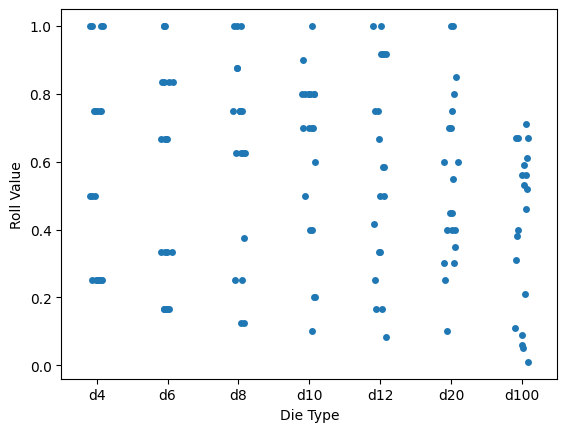

In [38]:
#plots strip plot
plot = sns.stripplot(x='Die_Type', y='Normalized', data=rolledStacked)
plot.set_ylabel('Roll Value')
plot.set_xlabel('Die Type')

In [54]:
rolls = pd.read_excel('dieRollsStatic.xlsx').reset_index() # read the data
rolledStacked = rolls.melt(id_vars=['index', 'Fingers Crossed'], var_name='Die_Type', value_name='Roll_Value') # melt the data
rolledStacked['Normalized'] = rolledStacked.apply(normalize, axis=1) # normalize the data

In [55]:
rolledStacked

,index,Fingers Crossed,Die_Type,Roll_Value,Normalized
0,0,Yes,d4,1,0.25
1,1,No,d4,4,1.00
2,2,No,d4,1,0.25
3,3,No,d4,1,0.25
4,4,Yes,d4,3,0.75
...,...,...,...,...,...
135,15,No,d100,31,0.31
136,16,Yes,d100,61,0.61
137,17,Yes,d100,38,0.38
138,18,Yes,d100,56,0.56


(-0.1, 1.4)

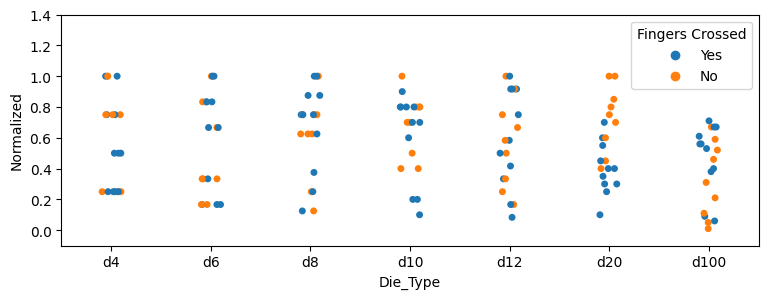

In [91]:
fig, ax = plt.subplots(figsize=(9, 3))
sns.stripplot(data=rolledStacked, x='Die_Type', y='Normalized', ax=ax,
              hue='Fingers Crossed')

ax.set_ylim([-0.1, 1.4])

In [68]:
rolledStacked.pivot(index=['index', 'Fingers Crossed'], columns='Die_Type', values='Roll_Value').reset_index() # pivot the data

Die_Type,index,Fingers Crossed,d10,d100,d12,d20,d4,d6,d8
0,0,Yes,2,67,11,2,1,1,6
1,1,No,8,21,6,8,4,2,5
2,2,No,7,67,8,20,1,4,6
3,3,No,4,59,3,16,1,2,1
4,4,Yes,7,56,7,8,3,2,7
5,5,Yes,8,9,1,12,2,5,3
6,6,No,8,46,2,12,1,4,5
7,7,Yes,8,53,6,11,1,1,7
8,8,No,7,5,9,9,3,2,8
9,9,No,10,1,7,20,3,1,6


In [74]:
rolls.describe()

,index,d4,d6,d8,d10,d12,d20,d100
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,9.50000,2.250000,3.350000,5.150000,6.350000,7.050000,10.950000,40.850000
std,5.91608,1.208522,1.899446,2.230766,2.518876,3.619756,5.010253,24.002796
min,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
25%,4.75000,1.000000,1.750000,4.500000,4.750000,4.000000,7.750000,18.500000
50%,9.50000,2.000000,4.000000,6.000000,7.000000,7.000000,10.000000,49.000000
75%,14.25000,3.000000,5.000000,6.250000,8.000000,11.000000,14.250000,59.500000
max,19.00000,4.000000,6.000000,8.000000,10.000000,12.000000,20.000000,71.000000


In [75]:
rolls.groupby(by='Fingers Crossed').mean() # group the data by 'Fingers Crossed' and calculate the mean

,index,d4,d6,d8,d10,d12,d20,d100
Fingers Crossed,,,,,,,,
No,7.777778,2.333333,3.000000,4.888889,6.777778,6.888889,14.555556,32.555556
Yes,10.909091,2.181818,3.636364,5.363636,6.000000,7.181818,8.000000,47.636364


In [86]:
def perc25(data):
    return np.percentile(data, 25) # calculate the 25th percentile

In [89]:
rolls.groupby(by='Fingers Crossed').agg(perc25) # group the data by 'Fingers Crossed' and calculate the average

,index,d4,d6,d8,d10,d12,d20,d100
Fingers Crossed,,,,,,,,
No,3.0,1.0,2.0,5.0,5.0,4.0,12.0,11.0
Yes,6.0,1.0,1.5,4.0,4.0,4.5,6.0,39.0
